homoscedastic

Epoch 0 | NLL Loss: 0.4508 | σ²: 0.9990
Epoch 100 | NLL Loss: 0.1087 | σ²: 0.9000
Epoch 200 | NLL Loss: 0.0639 | σ²: 0.8119
Epoch 300 | NLL Loss: 0.0269 | σ²: 0.7352
Epoch 400 | NLL Loss: -0.0048 | σ²: 0.6679
Epoch 500 | NLL Loss: -0.0324 | σ²: 0.6090
Epoch 600 | NLL Loss: -0.0570 | σ²: 0.5575
Epoch 700 | NLL Loss: -0.0789 | σ²: 0.5123
Epoch 800 | NLL Loss: -0.0981 | σ²: 0.4727
Epoch 900 | NLL Loss: -0.1147 | σ²: 0.4382


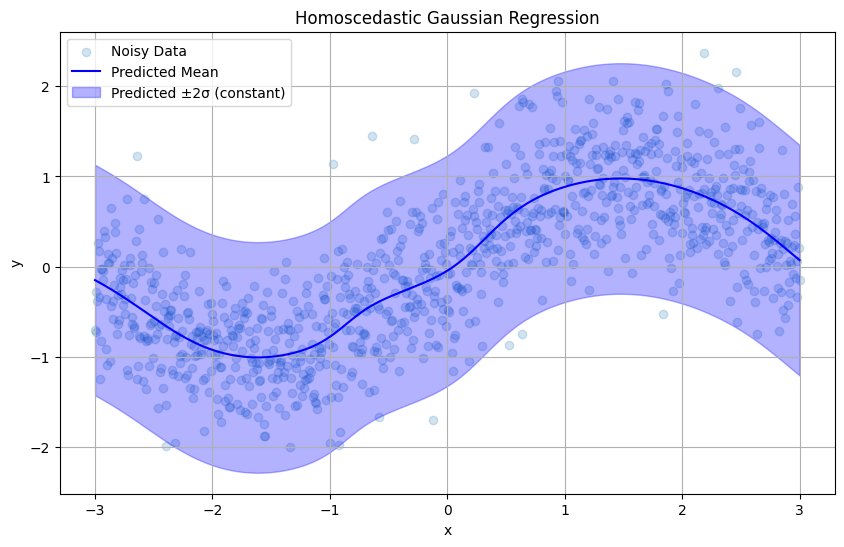

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Step 1: Generate synthetic homoscedastic data
torch.manual_seed(0)
n_samples = 1000
x = torch.linspace(-3, 3, n_samples).unsqueeze(1)
true_mu = torch.sin(x)
true_sigma = 0.5  # Constant noise
y = true_mu + true_sigma * torch.randn_like(x)

# Step 2: Model that predicts only mean
class HomoscedasticRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)  ######################################################### Only predicting mu
        )
        # log_variance is a learnable parameter (global)
        self.log_var = nn.Parameter(torch.tensor(0.0))  # Initialize to log(1)

    def forward(self, x):
        mu = self.net(x)
        return mu, self.log_var

# Step 3: NLL Loss Function
def nll_loss(y, mu, log_var):
    return 0.5 * (log_var + (y - mu)**2 / torch.exp(log_var)).mean()

# Step 4: Train the model
model = HomoscedasticRegressor()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1000):
    model.train()
    mu_pred, log_var_pred = model(x)
    loss = nll_loss(y, mu_pred, log_var_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | NLL Loss: {loss.item():.4f} | σ²: {torch.exp(log_var_pred).item():.4f}")

# Step 5: Visualization
model.eval()
with torch.no_grad():
    mu_pred, log_var_pred = model(x)
    sigma = torch.exp(0.5 * log_var_pred).item()  # scalar

x_np = x.numpy().flatten()
y_np = y.numpy().flatten()
mu_np = mu_pred.numpy().flatten()

plt.figure(figsize=(10, 6))
plt.scatter(x_np, y_np, alpha=0.2, label='Noisy Data')
plt.plot(x_np, mu_np, color='blue', label='Predicted Mean')
plt.fill_between(x_np, mu_np - 2*sigma, mu_np + 2*sigma, color='blue', alpha=0.3, label='Predicted ±2σ (constant)')
plt.legend()
plt.title("Homoscedastic Gaussian Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

heteroscedastic

Epoch 0 | NLL Loss: 1.5983
Epoch 100 | NLL Loss: 0.4873
Epoch 200 | NLL Loss: 0.4627
Epoch 300 | NLL Loss: 0.4561
Epoch 400 | NLL Loss: 0.4529
Epoch 500 | NLL Loss: 0.4508
Epoch 600 | NLL Loss: 0.4493
Epoch 700 | NLL Loss: 0.4480
Epoch 800 | NLL Loss: 0.4468
Epoch 900 | NLL Loss: 0.4458


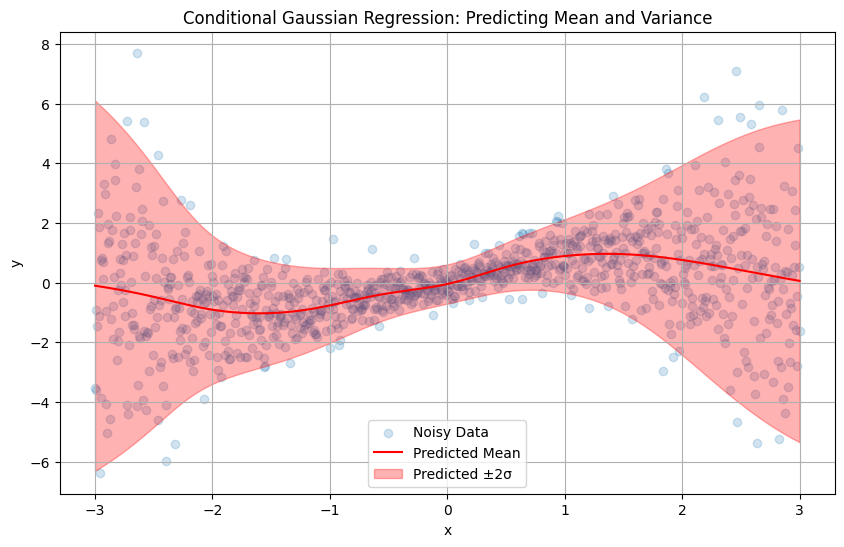

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Generate synthetic data
torch.manual_seed(0)
n_samples = 1000
x = torch.linspace(-3, 3, n_samples).unsqueeze(1)
true_mu = torch.sin(x)
true_sigma = 0.3 + 0.3 * (x**2)
y = true_mu + true_sigma * torch.randn_like(x)

# Step 2: Define model
class GaussianRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 2)  #################################################### Outputs: [mu, log_variance] this is the diff bw
        )

    def forward(self, x):
        out = self.net(x)
        mu = out[:, 0].unsqueeze(1)
        log_var = out[:, 1].unsqueeze(1)
        return mu, log_var

# Step 3: NLL Loss Function
def nll_loss(y, mu, log_var):
    return 0.5 * (log_var + (y - mu)**2 / torch.exp(log_var)).mean()

# Step 4: Training
model = GaussianRegressor()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1000):
    model.train()
    mu_pred, log_var_pred = model(x)
    loss = nll_loss(y, mu_pred, log_var_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | NLL Loss: {loss.item():.4f}")

# Step 5: Visualization
model.eval()
with torch.no_grad():
    mu_pred, log_var_pred = model(x)
    sigma_pred = torch.exp(0.5 * log_var_pred)

x_np = x.numpy().flatten()
y_np = y.numpy().flatten()
mu_np = mu_pred.numpy().flatten()
sigma_np = sigma_pred.numpy().flatten()

plt.figure(figsize=(10, 6))
plt.scatter(x_np, y_np, alpha=0.2, label='Noisy Data')
plt.plot(x_np, mu_np, color='red', label='Predicted Mean')
plt.fill_between(x_np, mu_np - 2*sigma_np, mu_np + 2*sigma_np, color='red', alpha=0.3, label='Predicted ±2σ')
plt.legend()
plt.title("Conditional Gaussian Regression: Predicting Mean and Variance")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

Epoch 0: Loss = 0.3740
Epoch 200: Loss = -0.7928
Epoch 400: Loss = -0.8032
Epoch 600: Loss = -0.8134
Epoch 800: Loss = -0.8246


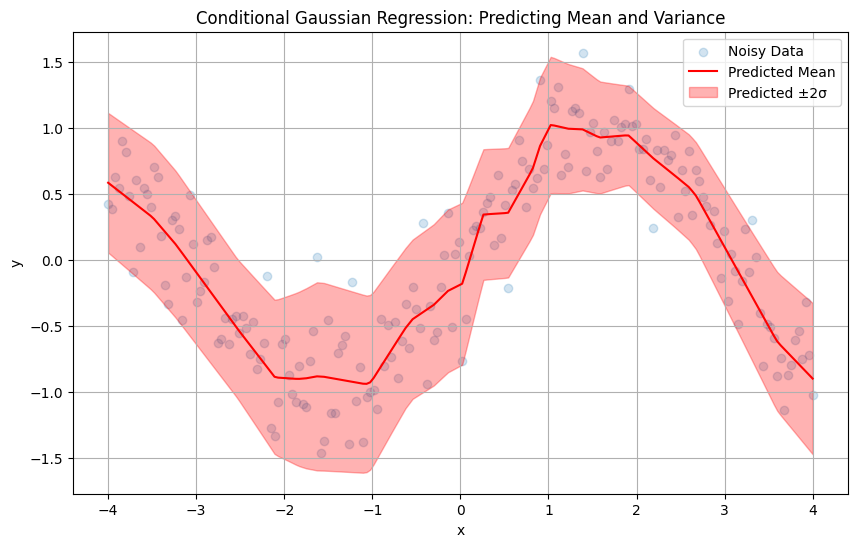

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Generate toy 1D data: y = sin(x) + noise
torch.manual_seed(0)
x = torch.linspace(-4, 4, 200).unsqueeze(1)
y = torch.sin(x) + torch.randn_like(x) * 0.3  # Add noise

# Define NN that outputs mean and log precision
class Uncertainty1DNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc_mean = nn.Linear(64, 1)
        self.fc_log_precision = nn.Linear(64, 1)

    def forward(self, x):
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        mean = self.fc_mean(h)
        log_precision = self.fc_log_precision(h)
        precision = torch.exp(log_precision)
        return mean, precision

# Negative log-likelihood loss
def nll_loss(y_pred_mean, y_pred_precision, y_true):
    return 0.5 * torch.mean(
        y_pred_precision * (y_true - y_pred_mean)**2 - torch.log(y_pred_precision)
    )

# Initialize model
model = Uncertainty1DNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop
for epoch in range(1000):
    model.train()
    optimizer.zero_grad()
    mean, precision = model(x)
    loss = nll_loss(mean, precision, y)
    loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

# Switch to eval mode and make predictions
model.eval()
with torch.no_grad():
    mu, precision = model(x)
    sigma = torch.sqrt(1 / precision)

# Convert tensors to NumPy for plotting
x_np = x.squeeze().numpy()
y_np = y.squeeze().numpy()
mu_np = mu.squeeze().numpy()
sigma_np = sigma.squeeze().numpy()

# Sort for smooth plotting
sorted_idx = np.argsort(x_np)
x_np = x_np[sorted_idx]
y_np = y_np[sorted_idx]
mu_np = mu_np[sorted_idx]
sigma_np = sigma_np[sorted_idx]

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(x_np, y_np, alpha=0.2, label='Noisy Data')
plt.plot(x_np, mu_np, color='red', label='Predicted Mean')
plt.fill_between(x_np, mu_np - 2*sigma_np, mu_np + 2*sigma_np, color='red', alpha=0.3, label='Predicted ±2σ')
plt.legend()
plt.title("Conditional Gaussian Regression: Predicting Mean and Variance")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

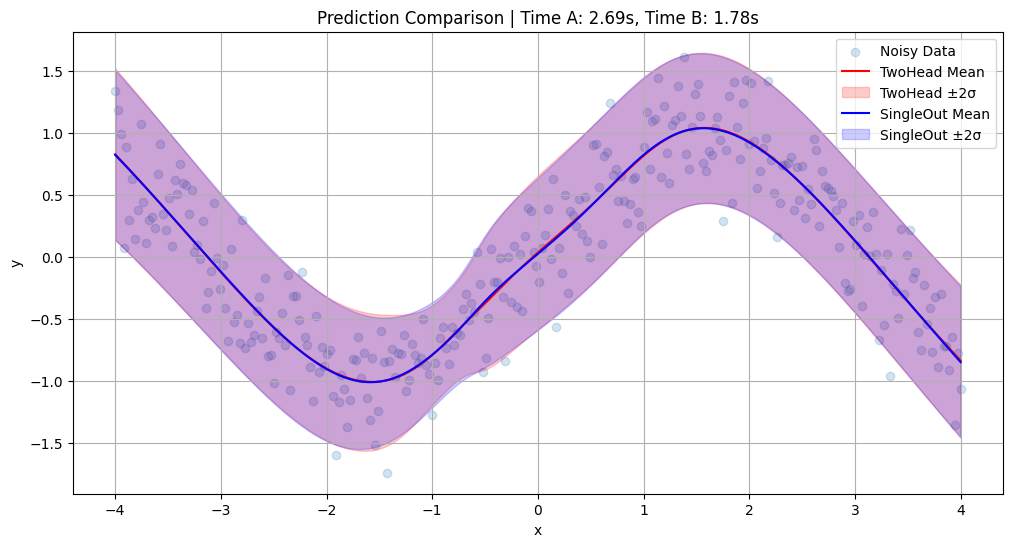

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import time

# 1. Generate toy data: y = sin(x) + noise
torch.manual_seed(42)
x = torch.linspace(-4, 4, 300).unsqueeze(1)
y = torch.sin(x) + 0.3 * torch.randn_like(x)

# 2. Loss function: Negative log-likelihood
def gaussian_nll(mu, log_var, target):
    precision = torch.exp(-log_var)
    return 0.5 * torch.mean(precision * (target - mu)**2 + log_var)

# 3. Model A: Two separate heads
class TwoHeadNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh()
        )
        self.mu_head = nn.Linear(64, 1)
        self.log_var_head = nn.Linear(64, 1)

    def forward(self, x):
        h = self.shared(x)
        mu = self.mu_head(h)
        log_var = self.log_var_head(h)
        return mu, log_var

# 4. Model B: Single output layer
class SingleOutputNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 2)  # [mu, log_var]
        )

    def forward(self, x):
        out = self.net(x)
        mu = out[:, 0:1]
        log_var = out[:, 1:2]
        return mu, log_var

# 5. Train function
def train_model(model, x, y, epochs=1000):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    start = time.time()
    for _ in range(epochs):
        optimizer.zero_grad()
        mu, log_var = model(x)
        loss = gaussian_nll(mu, log_var, y)
        loss.backward()
        optimizer.step()
    return model, time.time() - start

# Train both models
modelA, timeA = train_model(TwoHeadNN(), x, y)
modelB, timeB = train_model(SingleOutputNN(), x, y)

# 6. Predict and plot
def predict_and_plot(model, label, color):
    model.eval()
    with torch.no_grad():
        mu, log_var = model(x)
        sigma = torch.sqrt(torch.exp(log_var))

    x_np = x.squeeze().numpy()
    y_np = y.squeeze().numpy()
    mu_np = mu.squeeze().numpy()
    sigma_np = sigma.squeeze().numpy()

    idx = np.argsort(x_np)
    x_np, mu_np, sigma_np = x_np[idx], mu_np[idx], sigma_np[idx]

    plt.plot(x_np, mu_np, color=color, label=f'{label} Mean')
    plt.fill_between(x_np, mu_np - 2*sigma_np, mu_np + 2*sigma_np,
                     color=color, alpha=0.2, label=f'{label} ±2σ')

# Final plot
plt.figure(figsize=(12, 6))
plt.scatter(x.numpy(), y.numpy(), alpha=0.2, label='Noisy Data')

predict_and_plot(modelA, "TwoHead", "red")
predict_and_plot(modelB, "SingleOut", "blue")

plt.legend()
plt.title(f"Prediction Comparison | Time A: {timeA:.2f}s, Time B: {timeB:.2f}s")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

one head is better than 2 head